# Utah Police Incident Analysis Using ANOVA

## Loading Packages

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm 

## Loading in the Data

In [91]:
crime_summary = pd.read_csv("crime_summary.csv")
crime_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_rate_per_100k  514 non-null    float64
 1   city                    514 non-null    object 
 2   season                  514 non-null    object 
 3   year                    514 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 16.2+ KB


## Visulizing the data

### Box-Plot of Seasons 

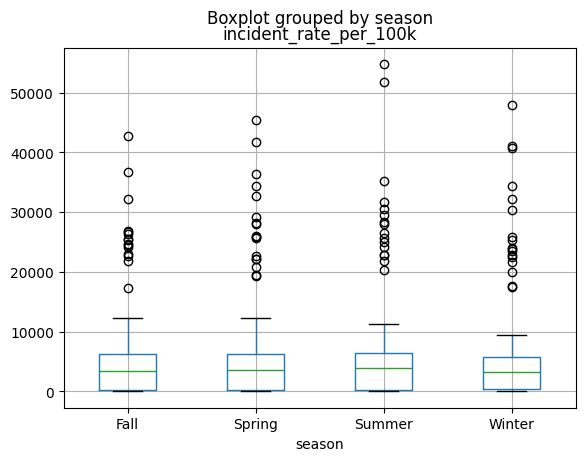

In [92]:
crime_summary.boxplot(
    column="incident_rate_per_100k",
    by="season"
)
plt.show()

The boxplot indicates that incident rates per 100,000 are fairly consistent across seasons. Although each season exhibits some outliers, the medians and interquartile ranges are similar, suggesting that seasonal differences in incident rates are minimal.

## Building an ANOVA Model

In [93]:
model = ols(
    "incident_rate_per_100k ~ C(season) * C(city) + C(year)",
    data=crime_summary
).fit()
anova_table = sm.stats.anova_lm(model, typ=3)
print(anova_table)

                         sum_sq     df          F        PR(>F)
Intercept          3.834505e+07    1.0   3.675239  5.588408e-02
C(season)          1.800786e+05    3.0   0.005753  9.993990e-01
C(city)            7.777213e+09   17.0  43.848157  6.489150e-83
C(year)            6.254757e+08    9.0   6.661073  6.041384e-09
C(season):C(city)  3.654698e+08   51.0   0.686843  9.505255e-01
Residual           4.517640e+09  433.0        NaN           NaN


The ANOVA model indicates that incident rates per 100,000 vary significantly by city and year, but not by season. City has a very strong effect (p ≈ 6.49e-83), showing large differences in incident rates across locations, and year is also statistically significant (p ≈ 6.04e-09), indicating that incident rates change over time. In contrast, season has no meaningful effect (p ≈ 0.999), suggesting no detectable seasonal variation in incident rates. Additionally, the interaction between season and city is not significant (p ≈ 0.95), meaning that seasonal patterns do not differ across cities. Overall, this model suggests that spatial and temporal factors drive variation in incident rates, while seasonal effects do not contribute meaningfully.

## Interpreting the Model

### Q-Q plot

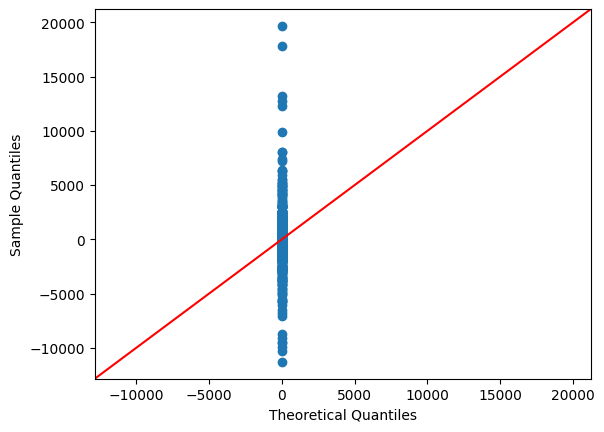

In [94]:
sm.qqplot(model.resid, line='45')
plt.show()

<Axes: ylabel='Count'>

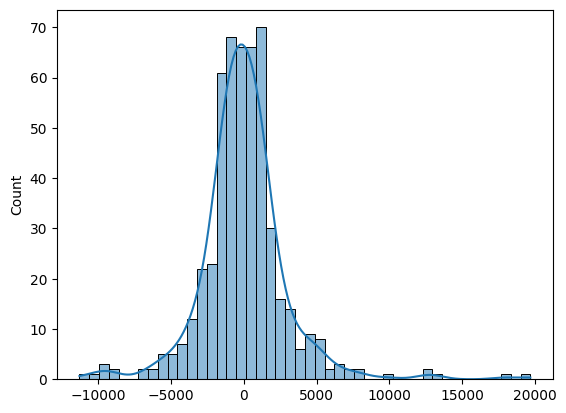

In [95]:
sns.histplot(model.resid, kde=True)

The ANOVA results show that incident rates per 100,000 are strongly influenced by city and year, while season and the season-by-city interaction are not statistically significant. However, a key issue with the model is seen in the residuals: they are not well-behaved under the raw scale. The residual distribution is highly influenced by the skewed nature of the data and the wide range of incident rates across cities, which leads to non-ideal assumptions for ANOVA. In particular, the residuals reflect heteroskedasticity (unequal variance across groups) and non-normal structure in the original scale, meaning the model fit is driven heavily by large city effects and does not stabilize variance well without transformation.

## Log Model

In [96]:
crime_summary["log_incident_rate"] = np.log1p(crime_summary["incident_rate_per_100k"])
log_model = ols(
    "log_incident_rate ~ C(season) * C(city) + C(year)",
    data=crime_summary
).fit()
log_anova_table = sm.stats.anova_lm(log_model, typ=3)
print(log_anova_table)

                        sum_sq     df          F        PR(>F)
Intercept            36.846636    1.0  14.765684  1.399518e-04
C(season)            11.073736    3.0   1.479206  2.195269e-01
C(city)             580.239491   17.0  13.677732  4.171162e-31
C(year)             110.927212    9.0   4.939140  2.494684e-06
C(season):C(city)   101.856756   51.0   0.800342  8.355023e-01
Residual           1080.518380  433.0        NaN           NaN


The log-transformed ANOVA results indicate that incident rates per 100,000 are significantly influenced by both city and year, while season does not have a statistically significant effect. City shows a very strong effect (p ≈ 4.17e-31), suggesting substantial differences in incident rates across locations, and year is also significant (p ≈ 2.49e-06), indicating that rates change over time. In contrast, season is not significant (p = 0.219), meaning there is no evidence of meaningful seasonal variation in incident rates. Additionally, the interaction between season and city is not significant (p = 0.835), showing that seasonal patterns do not differ across cities. Overall, the model suggests that spatial and temporal factors, rather than seasonal effects, are the primary drivers of variation in incident rates.

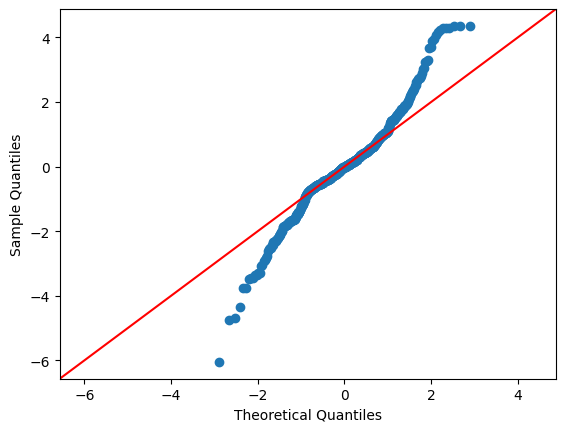

In [97]:
sm.qqplot(log_model.resid, line='45')
plt.show()

<Axes: ylabel='Count'>

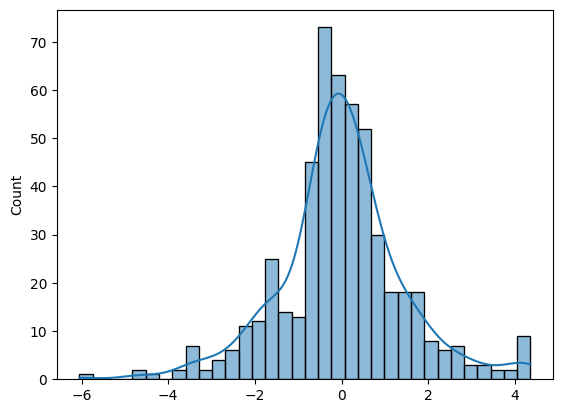

In [98]:
sns.histplot(log_model.resid, kde=True)

## Comparing Both Models 

In [99]:
print("Original AIC:", model.aic)
print("Log model AIC:", log_model.aic)

print("Original BIC:", model.bic)
print("Log model BIC:", log_model.bic)

Original AIC: 9839.03140748443
Log model AIC: 2002.5568936980935
Original BIC: 10182.651491986298
Log model BIC: 2346.176978199962


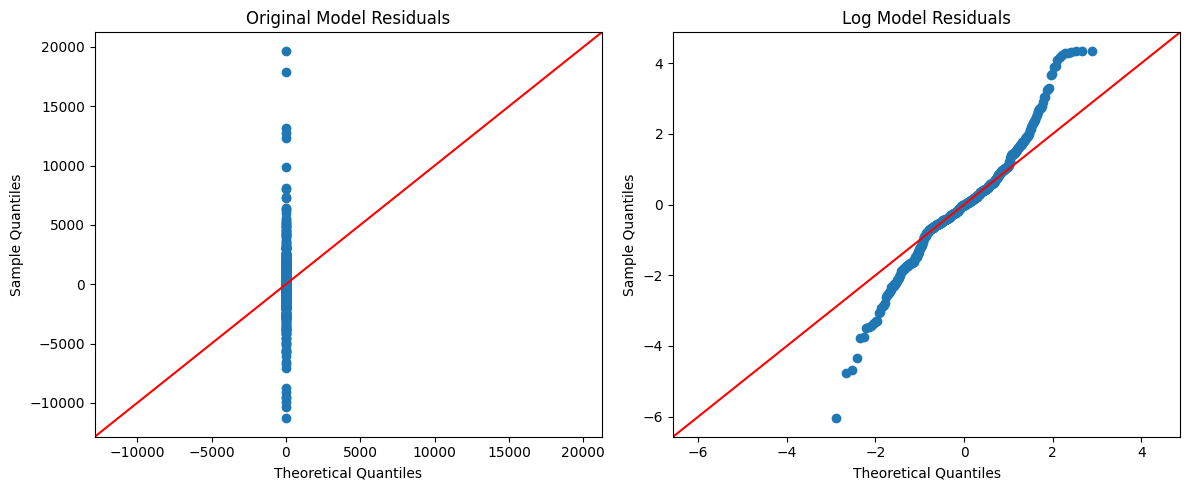

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sm.qqplot(model.resid, line='45', ax=axes[0])
axes[0].set_title("Original Model Residuals")

sm.qqplot(log_model.resid, line='45', ax=axes[1])
axes[1].set_title("Log Model Residuals")

plt.tight_layout()
plt.show()

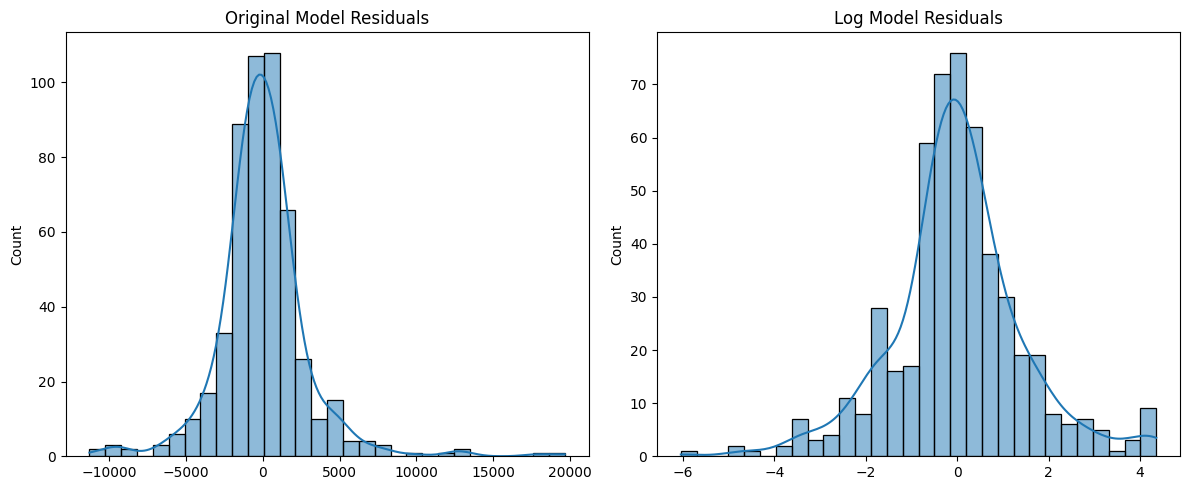

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(model.resid, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Model Residuals")

sns.histplot(log_model.resid, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log Model Residuals")

plt.tight_layout()
plt.show()

The AIC and BIC values show a substantial improvement in model fit after applying the log transformation to incident rates per 100,000. Both AIC (9839.03 → 2002.56) and BIC (10182.65 → 2346.18) decrease dramatically, indicating that the log-transformed model provides a much better balance of goodness-of-fit and model simplicity compared to the original model. This aligns with earlier diagnostic evidence showing that the original model suffered non-constant variance, and poorly behaved residuals, while the log transformation helped stabilize variance and improve normality. Importantly, despite the large improvement in model fit, the overall conclusions remain consistent across both models: city and year are significant predictors of incident rates, while season and the season-by-city interaction are not statistically significant.